# Data Analysis (coupler_NCap_cap_matrix)
## Qiskit Metal --> Capacitance

Ansys surrogate model

## Configuration

Disable cell scrolling.

Parameters are stored in a shared script.

In [44]:
from parameters_surrogate import *

In [46]:
# make directory for data and scaler saving
os.makedirs('scalers', exist_ok=True)
os.makedirs(f'{DATA_DIR}', exist_ok=True)
os.makedirs(f'{DATA_DIR}/npy', exist_ok=True)

## Library

In [73]:
import json
import numpy as np
import pandas as pd
from pandas import json_normalize
import joblib
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

## Datasets

### Load
From https://huggingface.co/datasets/SQuADDS/SQuADDS_DB/tree/main

In [48]:
df = pd.read_json("coupler-NCap-cap_matrix.json")

### Look at the data and structure

In [49]:
#look at the first value
first_entry = df.iloc[100]

# Print the headers and their corresponding values
for header, value in first_entry.items():
    print(f"{header}: {value}")

sim_options: {'setup': {'name': 'lom_setup', 'reuse_selected_design': False, 'reuse_setup': False, 'freq_ghz': 5.0, 'save_fields': False, 'enabled': True, 'max_passes': 15, 'min_passes': 2, 'min_converged_passes': 2, 'percent_error': 0.1, 'percent_refinement': 30, 'auto_increase_solution_order': 'False', 'solution_order': 'Medium', 'solver_type': 'Iterative', 'run': {'name': 'LOMv2.01', 'components': ['cplr'], 'open_terminations': [['cplr', 'second_end'], ['cplr', 'prime_start'], ['cplr', 'prime_end']], 'box_plus_buffer': True}}, 'simulator': 'Ansys HFSS'}
sim_results: {'top_to_top': 38.61105, 'top_to_bottom': 12.01876, 'top_to_ground': 26.22814, 'bottom_to_bottom': 54.87869, 'bottom_to_ground': 42.33799, 'ground_to_ground': 103.60583, 'units': 'fF'}
design: {'design_options': {'prime_width': '11.7um', 'prime_gap': '5.1um', 'second_width': '11.7um', 'second_gap': '5.1um', 'cap_gap': '4.1um', 'cap_width': '12.9um', 'cap_gap_ground': '5.1um', 'finger_length': '25.9um', 'finger_count': '5

In [50]:
#Look at the headers relevant for us, to start lets only look at the sim_results (our x data) and design (our y data)
sim_results_column = df['sim_results']
print(sim_results_column, '\n\n')

design_column = df['design']
print(design_column)

0      {'top_to_top': 15.654910000000001, 'top_to_bot...
1      {'top_to_top': 65.85844, 'top_to_bottom': 36.2...
2      {'top_to_top': 18.77838, 'top_to_bottom': 2.88...
3      {'top_to_top': 42.46632, 'top_to_bottom': 21.0...
4      {'top_to_top': 43.49158, 'top_to_bottom': 18.4...
                             ...                        
425    {'top_to_top': 20.16504, 'top_to_bottom': 1.02...
426    {'top_to_top': 21.23155, 'top_to_bottom': 3.57...
427    {'top_to_top': 45.47336, 'top_to_bottom': 16.3...
428    {'top_to_top': 18.15142, 'top_to_bottom': 3.52...
429    {'top_to_top': 40.05013, 'top_to_bottom': 15.8...
Name: sim_results, Length: 430, dtype: object 


0      {'design_options': {'prime_width': '11.7um', '...
1      {'design_options': {'prime_width': '11.7um', '...
2      {'design_options': {'prime_width': '11.7um', '...
3      {'design_options': {'prime_width': '11.7um', '...
4      {'design_options': {'prime_width': '11.7um', '...
                             ...       

In [51]:
#take a look at everything in the design dataset
# Flatten the design column
design_flat = json_normalize(df['design'])

# List all column headers
design_column_vals = design_flat.columns.tolist()
print(design_column_vals)
print('length: ',len(design_column_vals))

['design_tool', 'coupler_type', 'design_options.prime_width', 'design_options.prime_gap', 'design_options.second_width', 'design_options.second_gap', 'design_options.cap_gap', 'design_options.cap_width', 'design_options.cap_gap_ground', 'design_options.finger_length', 'design_options.finger_count', 'design_options.cap_distance', 'design_options.orientation']
length:  13


### Reformat

In [52]:
#flatten what will be our capacitance data (Model 1's X, Model 2's Y)
X_cap = json_normalize(df['sim_results'])
# Dropping the 'units' column for now because they are all in fF and this info isnt useful
X_cap = X_cap.drop(columns=['units'])
print(X_cap)

     top_to_top  top_to_bottom  top_to_ground  bottom_to_bottom  \
0      15.65491        0.51663       14.95437          12.78614   
1      65.85844       36.28408       29.22434          94.96956   
2      18.77838        2.88026       15.65588          21.94864   
3      42.46632       21.05076       20.98596          55.18578   
4      43.49158       18.40010       24.77954          60.57606   
..          ...            ...            ...               ...   
425    20.16504        1.02606       18.87248          15.86284   
426    21.23155        3.57699       17.41757          28.43531   
427    45.47336       16.38109       28.66939          55.36257   
428    18.15142        3.52960       14.36617          23.20076   
429    40.05013       15.85270       23.83046          59.19318   

     bottom_to_ground  ground_to_ground  
0            12.09846          58.45017  
1            58.07364         124.18885  
2            18.77498          66.60369  
3            33.69106      

In [53]:
# Flatten the Qiskit Metal design parameters (Model 1's Y, Model 2's X)
y_design = json_normalize(df['design'])

columns_to_drop = ['design_tool','design_options.prime_width',
 'design_options.prime_gap',
 'design_options.second_width',
 'design_options.second_gap',
 'design_options.cap_gap_ground',
 'design_options.cap_distance',
 'design_options.orientation',
 'design_tool',
 'coupler_type']

y_design = y_design.drop(columns=columns_to_drop)

# Keep finger_count as a single numeric column (NO one-hot encoding)
# Just ensure it's a proper integer/float
fc_col = 'design_options.finger_count'
y_design[fc_col] = pd.to_numeric(y_design[fc_col], errors='coerce').astype(float)

print(f'finger_count kept as numeric column, unique values: {sorted(y_design[fc_col].unique())}')
print(f'y_design shape: {y_design.shape}')
print(y_design)

finger_count kept as numeric column, unique values: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
y_design shape: (430, 4)
    design_options.cap_gap design_options.cap_width  \
0                    2.1um                    4.9um   
1                    2.1um                   10.9um   
2                    4.1um                    6.9um   
3                    2.1um                    6.9um   
4                    4.1um                    8.9um   
..                     ...                      ...   
425                  2.1um                   10.9um   
426                  4.1um                   12.9um   
427                  4.1um                   10.9um   
428                  4.1um                    4.9um   
429                  2.1um                   14.9um   

    design_options.finger_length  design_options.finger_count  
0                         25.9um                          1.0  
1                         45.9um                          8.0  
2                 

### Validate and View Data

In [54]:
display(X_cap)

,top_to_top,top_to_bottom,top_to_ground,bottom_to_bottom,bottom_to_ground,ground_to_ground
0,15.65491,0.51663,14.95437,12.78614,12.09846,58.45017
1,65.85844,36.28408,29.22434,94.96956,58.07364,124.18885
2,18.77838,2.88026,15.65588,21.94864,18.77498,66.60369
3,42.46632,21.05076,20.98596,55.18578,33.69106,88.75992
4,43.49158,18.40010,24.77954,60.57606,41.62987,101.33585
...,...,...,...,...,...,...
425,20.16504,1.02606,18.87248,15.86284,14.59008,64.32406
426,21.23155,3.57699,17.41757,28.43531,24.50768,74.50121
427,45.47336,16.38109,28.66939,55.36257,38.54199,102.24635
428,18.15142,3.52960,14.36617,23.20076,19.39282,65.27181


In [55]:
display(y_design)

,design_options.cap_gap,design_options.cap_width,design_options.finger_length,design_options.finger_count
0,2.1um,4.9um,25.9um,1.0
1,2.1um,10.9um,45.9um,8.0
2,4.1um,6.9um,35.9um,2.0
3,2.1um,6.9um,45.9um,6.0
4,4.1um,8.9um,45.9um,6.0
...,...,...,...,...
425,2.1um,10.9um,35.9um,1.0
426,4.1um,12.9um,25.9um,2.0
427,4.1um,10.9um,45.9um,5.0
428,4.1um,4.9um,15.9um,4.0


## Transform Y to Numerical Values

We need all columns to be numeric floats for the MLP. This means stripping units like 'um' and 'nH',
converting to SI, and filling NaNs.

In [57]:
#look at the format all of the y values are in
for col in y_design.columns:
    print(f"{col}  {y_design[col].iloc[0]}")
print(y_design.shape)

design_options.cap_gap  2.1um
design_options.cap_width  4.9um
design_options.finger_length  25.9um
design_options.finger_count  1.0
(430, 4)


In [59]:
y_numerical = y_design.copy()

In [61]:
# Strip units (um, nH) and convert to SI
y_numerical_clean = y_numerical.copy()

# Extract numerical values and convert units (assuming 'um' for some columns)
um_cols = [col for col in y_numerical_clean.columns if y_numerical_clean[col].astype(str).str.contains('um').any()]

for col in um_cols:
    y_numerical_clean[col] = pd.to_numeric(y_numerical_clean[col].astype(str).str.replace('um', '', regex=False), errors='coerce') * 1e-6
    y_numerical_clean[col] = y_numerical_clean[col].round(15)

nH_cols = [col for col in y_numerical_clean.columns if y_numerical_clean[col].astype(str).str.contains('nH').any()]
for col in nH_cols:
    y_numerical_clean[col] = pd.to_numeric(y_numerical_clean[col].astype(str).str.replace('nH', '', regex=False), errors='coerce') * 1e-9
    y_numerical_clean[col] = y_numerical_clean[col].round(15)

for col in y_numerical_clean.columns:
    try:
        print(f"{col}-----------Numerical: {y_numerical_clean[col].iloc[0]}-----------Original: {y_design[col].iloc[0]}")
    except KeyError:
        print(f'{col} -- changed')

design_options.cap_gap-----------Numerical: 2.1e-06-----------Original: 2.1um
design_options.cap_width-----------Numerical: 4.9e-06-----------Original: 4.9um
design_options.finger_length-----------Numerical: 2.59e-05-----------Original: 25.9um
design_options.finger_count-----------Numerical: 1.0-----------Original: 1.0


In [62]:
# Print how many columns have NaN in them
for col in y_design.columns:
    total = len(y_design[col])
    n_nan = y_design[col].isna().sum()
    if 0 < n_nan < total:
        pct_nan = n_nan / total * 100
        zero_mask = y_design[col].astype(str).str.contains('0.0', na=False)
        n_zero = zero_mask.sum()
        pct_zero = n_zero / total * 100
        print(f"{col}:")
        print(f"  NaN values:  {n_nan}/{total}  ({pct_nan:.2f}%)")
        print(f"  '0.0' vals:  {n_zero}/{total}  ({pct_zero:.2f}%)")
        print()

In [63]:
# Fill NaN with 1 (same as original notebook)
y_numerical_clean.fillna(float(1), inplace=True)

print('Now all of these should be numerical:')
for col in y_numerical_clean.columns:
    print(f"{col}-----------{y_numerical_clean[col].iloc[0]}")

Now all of these should be numerical:
design_options.cap_gap-----------2.1e-06
design_options.cap_width-----------4.9e-06
design_options.finger_length-----------2.59e-05
design_options.finger_count-----------1.0


In [64]:
y_final = y_numerical_clean.copy()
print('Final y shape:', y_final.shape)
display(y_final)

Final y shape: (430, 4)


,design_options.cap_gap,design_options.cap_width,design_options.finger_length,design_options.finger_count
0,0.000002,0.000005,0.000026,1.0
1,0.000002,0.000011,0.000046,8.0
2,0.000004,0.000007,0.000036,2.0
3,0.000002,0.000007,0.000046,6.0
4,0.000004,0.000009,0.000046,6.0
...,...,...,...,...
425,0.000002,0.000011,0.000036,1.0
426,0.000004,0.000013,0.000026,2.0
427,0.000004,0.000011,0.000046,5.0
428,0.000004,0.000005,0.000016,4.0


### Save the header names of the y data

In [65]:
filename = 'y_characteristics_linear_encoding.csv'
headers = list(y_final.columns)
with open(filename, 'w') as f:
    f.write(','.join(headers))
print(f'Saved {filename} with {len(headers)} columns')

Saved y_characteristics_linear_encoding.csv with 4 columns


## Visualize

### X Data (Capacitance values)

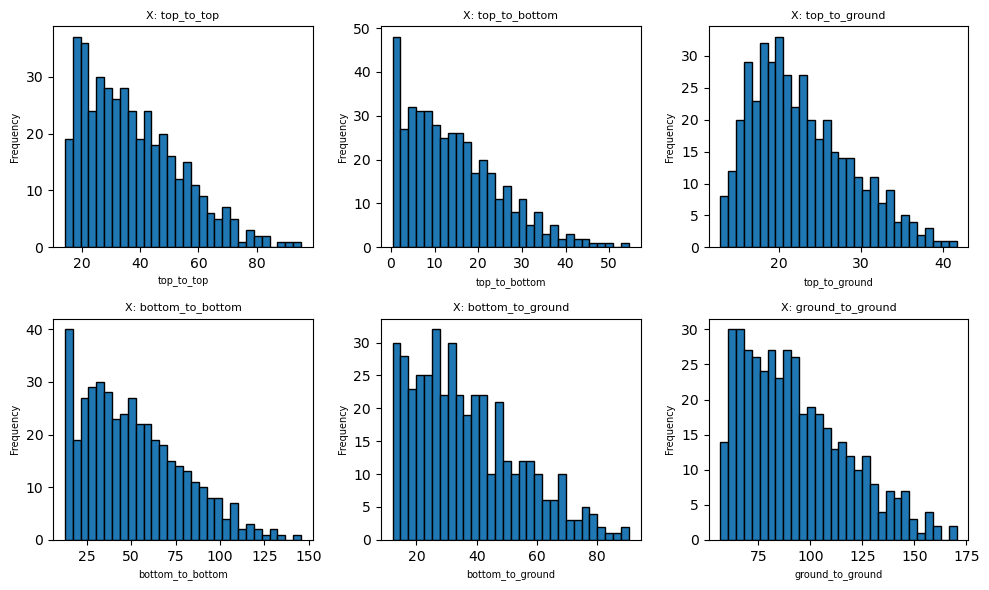

In [67]:
num_cols = len(X_cap.columns)
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i, col in enumerate(X_cap.columns):
    axes[i].hist(X_cap[col], bins=30, edgecolor='black')
    axes[i].set_title(f'X: {col}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/model2_x_cap_distribution.pdf')
plt.show()

### Y Data (Qiskit Metal params)

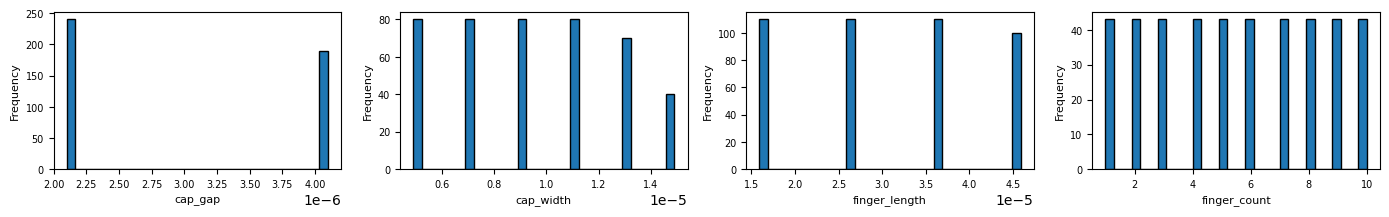

In [68]:
num_cols = len(y_final.columns)
num_rows = ((num_cols + 2) // 4) + 1

plt.figure(figsize=(14, 2 * num_rows))

for n, col in enumerate(y_final.columns):
    try:
        plt.subplot(num_rows, 4, n + 1)
        plt.hist(y_final[col], bins=30, edgecolor='black')
        plt.xlabel(col.split('design_options.')[-1], fontsize=8)
        plt.ylabel('Frequency', fontsize=8)
        plt.tick_params(axis='both', which='major', labelsize=7)
    except TypeError:
        print(f"Warning: Column '{col}' is not numeric and cannot be plotted.")

plt.tight_layout()
plt.savefig('plots/model2_unscaled_y_design_distribution.png')
plt.show()

In [69]:
plt.close()

## Split

Dataset split is 70%-15%-15% training-validation-test. We use a constant state (seed) for reproducible splits.

In [71]:
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X_cap, y_final, test_size=0.3, random_state=42, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=0.5, random_state=42, shuffle=True
)

In [72]:
total = y_train.shape[0] + y_test.shape[0] + y_val.shape[0]
print('---------------------------------------')
print('Train set shape: {}, {:.2f}%'.format(y_train.shape, (y_train.shape[0]*100.)/total))
print('Validation set shape: {}, {:.2f}%'.format(y_val.shape, (y_val.shape[0]*100.)/total))
print('Test set shape: {}, {:.2f}%'.format(y_test.shape, (y_test.shape[0]*100.)/total))
print('---------------------------------------')

---------------------------------------
Train set shape: (301, 4), 70.00%
Validation set shape: (64, 4), 14.88%
Test set shape: (65, 4), 15.12%
---------------------------------------


## Augment

### Scale X (Capacitance values)

Scale capacitance values to be between 0 and 1

In [74]:
def scale_splits_per_column(train_df, val_df, test_df, scaler_name_prefix):
    train_s = train_df.copy()
    val_s   = val_df.copy()
    test_s  = test_df.copy()

    scalers = {}
    for col in train_df.columns:
        sc = MinMaxScaler()
        sc.fit(train_df[[col]])

        train_s[col] = sc.transform(train_df[[col]])
        val_s[col]   = sc.transform(val_df[[col]])
        test_s[col]  = sc.transform(test_df[[col]])

        scalers[col] = sc
        joblib.dump(sc, f'scalers/{scaler_name_prefix}_{col}.save')

    return train_s, val_s, test_s, scalers

X_train_scaled, X_val_scaled, X_test_scaled, x_scalers = scale_splits_per_column(
    X_train, X_val, X_test,
    scaler_name_prefix='scaler_X_linear'
)

In [75]:
# look at the scaled stuff to check
display(X_train_scaled.head())
display(X_val_scaled.head())
display(X_test_scaled.head())

,top_to_top,top_to_bottom,top_to_ground,bottom_to_bottom,bottom_to_ground,ground_to_ground
402,0.250805,0.209907,0.330639,0.300816,0.362192,0.363198
118,0.403006,0.335853,0.521963,0.448767,0.525134,0.532313
114,0.095051,0.012208,0.264673,0.023431,0.031640,0.092625
137,0.906190,0.927436,0.816707,0.892457,0.867842,0.869796
318,0.030792,0.032401,0.047885,0.064245,0.085701,0.078035


,top_to_top,top_to_bottom,top_to_ground,bottom_to_bottom,bottom_to_ground,ground_to_ground
152,0.352658,0.303826,0.436994,0.385637,0.438489,0.444398
73,0.790058,0.780766,0.769177,0.795186,0.804246,0.811902
22,0.048374,0.019961,0.122090,0.043696,0.059860,0.071370
16,0.450062,0.377039,0.575686,0.420071,0.449994,0.493731
18,0.264011,0.221582,0.343881,0.274416,0.308952,0.324349


,top_to_top,top_to_bottom,top_to_ground,bottom_to_bottom,bottom_to_ground,ground_to_ground
275,0.008322,0.005650,0.036568,0.006921,0.008502,0.011026
220,0.091476,0.064207,0.158028,0.111460,0.142611,0.146250
278,0.402785,0.367666,0.463301,0.414302,0.443569,0.458855
253,0.404664,0.351577,0.497000,0.324300,0.301817,0.357188
63,0.213806,0.207886,0.232536,0.231250,0.244814,0.241262


### Scale Y (Qiskit Metal params)

In [76]:
y_train_scaled, y_val_scaled, y_test_scaled, y_scalers = scale_splits_per_column(
    y_train, y_val, y_test,
    scaler_name_prefix='scaler_y_linear'
)

In [78]:
# look at the scaled stuff to check
display(y_train_scaled.head())
display(y_val_scaled.head())
display(y_test_scaled.head())

,design_options.cap_gap,design_options.cap_width,design_options.finger_length,design_options.finger_count
402,0.0,0.8,0.000000,0.444444
118,1.0,0.8,0.666667,0.555556
114,0.0,0.6,1.000000,0.000000
137,0.0,0.8,1.000000,1.000000
318,1.0,0.4,0.000000,0.111111


,design_options.cap_gap,design_options.cap_width,design_options.finger_length,design_options.finger_count
152,1.0,0.6,0.666667,0.555556
73,0.0,1.0,1.000000,0.777778
22,0.0,1.0,0.000000,0.000000
16,0.0,1.0,0.666667,0.444444
18,1.0,0.6,1.000000,0.333333


,design_options.cap_gap,design_options.cap_width,design_options.finger_length,design_options.finger_count
275,0.0,0.2,0.000000,0.000000
220,1.0,0.6,0.666667,0.111111
278,0.0,0.6,0.333333,0.666667
253,1.0,0.2,1.000000,0.666667
63,1.0,0.0,0.333333,0.777778


### Plot Scaled Data

### X

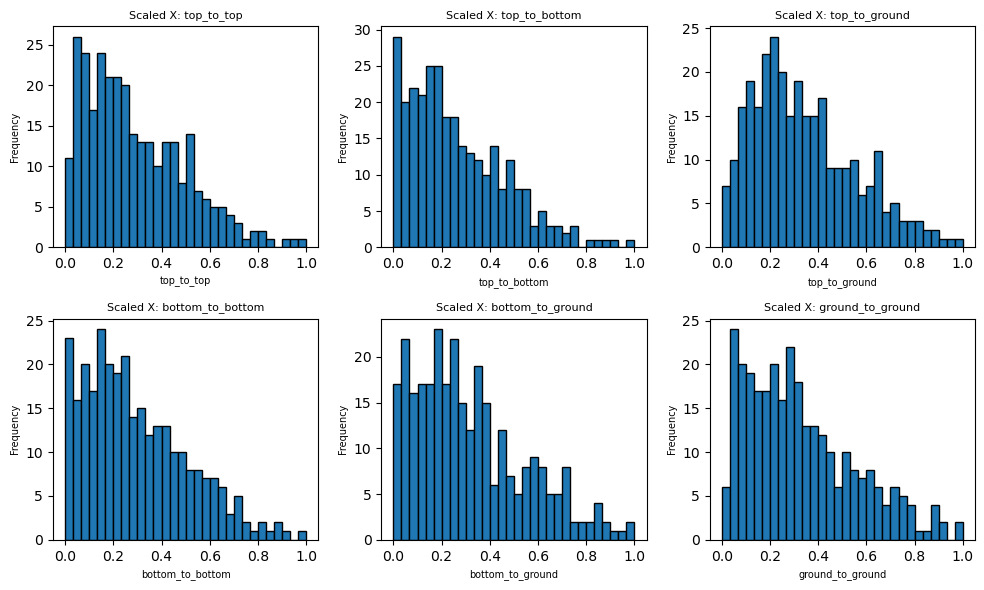

In [77]:
num_cols = len(X_cap.columns)
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i, col in enumerate(X_train_scaled.columns):
    axes[i].hist(X_train_scaled[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Scaled X: {col}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/model2_scaled_x_cap_distribution.pdf')
plt.show()

### Y

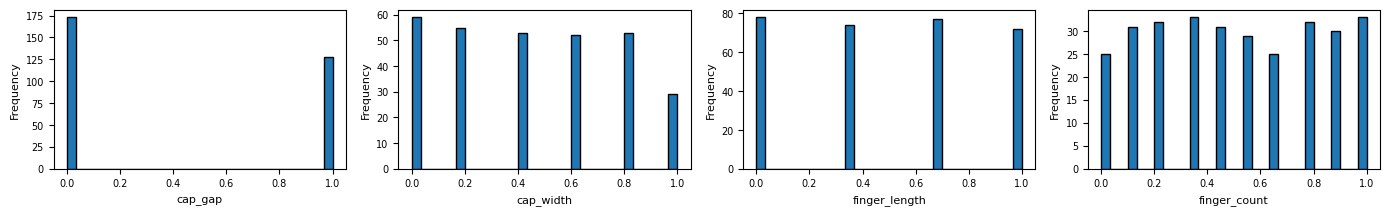

In [79]:
num_cols = len(y_train_scaled.columns)
num_rows = ((num_cols + 2) // 4) + 1

plt.figure(figsize=(14, 2 * num_rows))

for n, col in enumerate(y_train_scaled.columns):
    try:
        plt.subplot(num_rows, 4, n + 1)
        plt.hist(y_train_scaled[col], bins=30, edgecolor='black')
        plt.xlabel(col.split('design_options.')[-1], fontsize=8)
        plt.ylabel('Frequency', fontsize=8)
        plt.tick_params(axis='both', which='major', labelsize=7)
    except TypeError:
        print(f"Warning: Column '{col}' is not numeric and cannot be plotted.")

plt.tight_layout()
plt.savefig('plots/model2_scaled_y_design_distribution.png')
plt.show()

In [80]:
plt.close()

## Unscaling

To make sure we can recreate original values with saved scaler (compare with above cells)

### Unscale X

In [83]:
X_check = X_train_scaled
prefix = 'scaler_X_linear'

X_orig = X_check.copy()
for col in X_check.columns:
    sc = joblib.load(f'scalers/{prefix}_{col}.save')
    X_orig[col] = sc.inverse_transform(X_check[[col]])

display(X_orig.head())

,top_to_top,top_to_bottom,top_to_ground,bottom_to_bottom,bottom_to_ground,ground_to_ground
402,34.54206,11.72262,22.48642,52.67630,40.48964,97.98062
118,46.86221,18.53828,27.97364,72.33644,53.25255,117.17287
114,21.93432,1.02396,20.59449,15.81649,14.59800,67.27407
137,87.59318,50.55218,36.42698,131.29527,80.09630,155.47275
318,16.73280,2.11676,14.37695,21.23999,18.83252,65.61827


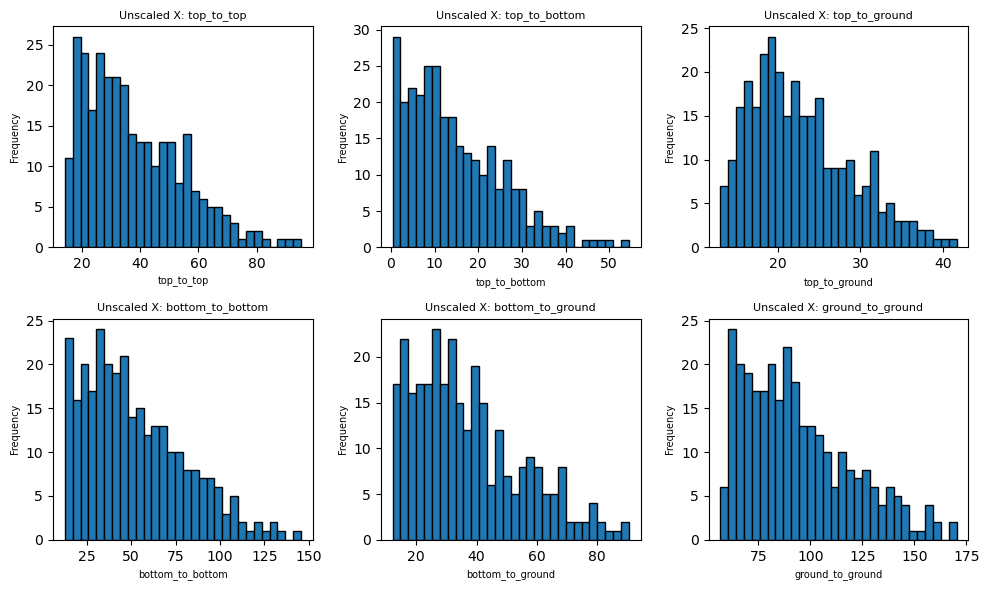

In [84]:
num_cols = len(X_cap.columns)
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i, col in enumerate(X_orig.columns):
    axes[i].hist(X_orig[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Unscaled X: {col}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/model2_unscaled_x_check.pdf')
plt.show()

### Unscale Y

In [85]:
prefix = 'scaler_y_linear'
y_orig = y_train_scaled.copy()

for col in y_train_scaled.columns:
    sc = joblib.load(f'scalers/{prefix}_{col}.save')
    y_orig[col] = sc.inverse_transform(y_train_scaled[[col]])

display(y_orig.head())

,design_options.cap_gap,design_options.cap_width,design_options.finger_length,design_options.finger_count
402,0.000002,0.000013,0.000016,5.0
118,0.000004,0.000013,0.000036,6.0
114,0.000002,0.000011,0.000046,1.0
137,0.000002,0.000013,0.000046,10.0
318,0.000004,0.000009,0.000016,2.0


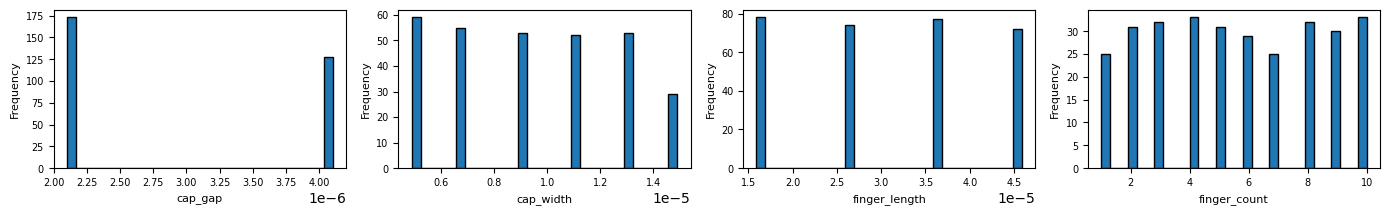

In [87]:
num_cols = len(y_orig.columns)
num_rows = ((num_cols + 2) // 4) + 1

plt.figure(figsize=(14, 2 * num_rows))

for j, col in enumerate(y_orig.columns):
    plt.subplot(num_rows, 4, j + 1)
    plt.hist(y_orig[col], bins=30, edgecolor='black')
    plt.xlabel(col.split('design_options.')[-1], fontsize=8)
    plt.ylabel('Frequency', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=7)


plt.tight_layout()
plt.savefig('plots/model2_unscaled_y_check.png')
plt.show()

## Save

In [88]:
!rm -f $DATA_DIR/npy/*npy

In [89]:
# Unscaled
np.save(f'{DATA_DIR}/npy/x_train_linear_encoding.npy', X_train)
np.save(f'{DATA_DIR}/npy/x_val_linear_encoding.npy', X_val)
np.save(f'{DATA_DIR}/npy/x_test_linear_encoding.npy', X_test)

np.save(f'{DATA_DIR}/npy/y_train_linear_encoding.npy', y_train)
np.save(f'{DATA_DIR}/npy/y_val_linear_encoding.npy', y_val)
np.save(f'{DATA_DIR}/npy/y_test_linear_encoding.npy', y_test)

print(f'Unscaled data saved in: {DATA_DIR}/npy')

Unscaled data saved in: data/npy


In [90]:
# Scaled
np.save(f'{DATA_DIR}/npy/x_train_linear_encoding_scaled.npy', X_train_scaled)
np.save(f'{DATA_DIR}/npy/x_val_linear_encoding_scaled.npy',   X_val_scaled)
np.save(f'{DATA_DIR}/npy/x_test_linear_encoding_scaled.npy',  X_test_scaled)

np.save(f'{DATA_DIR}/npy/y_train_linear_encoding_scaled.npy', y_train_scaled)
np.save(f'{DATA_DIR}/npy/y_val_linear_encoding_scaled.npy',   y_val_scaled)
np.save(f'{DATA_DIR}/npy/y_test_linear_encoding_scaled.npy',  y_test_scaled)

print(f'Scaled data saved in: {DATA_DIR}/npy')

Scaled data saved in: data/npy


In [41]:
!ls $DATA_DIR/npy/*npy

data/npy/x_test_linear_encoding.npy
data/npy/x_test_linear_encoding_scaled.npy
data/npy/x_train_linear_encoding.npy
data/npy/x_train_linear_encoding_scaled.npy
data/npy/x_val_linear_encoding.npy
data/npy/x_val_linear_encoding_scaled.npy
data/npy/y_test_linear_encoding.npy
data/npy/y_test_linear_encoding_scaled.npy
data/npy/y_train_linear_encoding.npy
data/npy/y_train_linear_encoding_scaled.npy
data/npy/y_val_linear_encoding.npy
data/npy/y_val_linear_encoding_scaled.npy


In [92]:
# saving column names (where capacitance=X_names, Qiskit params=y_columns)
with open('X_names', 'w') as f:
    f.write('\n'.join(X_cap.columns))

np.save('y_columns.npy', np.array(y_train.columns))
print(f'Saved X_names ({len(X_cap.columns)} cols) and y_columns.npy ({len(y_train.columns)} cols)')

Saved X_names (6 cols) and y_columns.npy (4 cols)
